## Project: CNN-based segmentation of cells in multi-modal microscopy images

Contact: Karl Rohr (Heidelberg University K.Rohr@dkfz-heidelberg.de)

### Introduction

Cell segmentation is a central task in biomedical image analysis and enables counting the cell number, quantifying single-cell fluorescence intensity, and tracking of cells to analyze cell motion. Challenges are high variation of cell shape and image intensity, strong image noise, low image contrast, and high cell density. Deep learning methods for cell segmentation in microscopy data show promising results.

### Goal

The goal of this project is to develop a Convolutional Neural Network (CNN) to automatically segment cells in microscopy images. A modified 2D U-Net model (Ronneberger et al., MICCAI 2015, Falk et al., Nature Methods 2019) will be implemented and applied to image data from different imaging modalities comprising fluorescence, differential interference contrast (DIC), and phase-contrast microscopy. Different versions of the network model will be generated by training on data from individual imaging modalities as well as a combination of different imaging modalities. The trained models are applied to the different datasets, and the segmentation accuracy will be quantified by a performance metric. The experimental results are analyzed and a comparison of the different network models will be carried out.

### Data and model

The [2D U-Net model](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28) will be used as a basis. Zero-padding (SAME padding) in the convolution layers should be included to ensure that the output size of the network is the same as the input size. This eliminates the need for cropping and resizing of the images in the original model. Experiments with different network configurations should be performed (e.g., different number of layers). Besides using a Cross-Entropy Loss as in the original model, a Dice Loss or a combination of both losses should be investigated. Also, loss weighting as in the original model should be tested. Existing implementations of the U-Net can be used as inspiration.

The network model should be applied to [datasets from the Cell Tracking Challenge](https://celltrackingchallenge.net/2d-datasets/) (Ulman et al., Nature Methods 2017) comprising 2D time-lapse microscopy image data of three different imaging modalities:
1. Fluorescence microscopy: HeLa cells stably expressing H2b-GFP ([download](http://data.celltrackingchallenge.net/training-datasets/Fluo-N2DL-HeLa.zip))
2. Differential interference contrast (DIC) microscopy: HeLa cells on a flat glass ([download](http://data.celltrackingchallenge.net/training-datasets/DIC-C2DH-HeLa.zip))
3. Phase-contrast microscopy: Glioblastoma-astrocytoma U373 cells on a polyacrylamide substrate ([download](http://data.celltrackingchallenge.net/training-datasets/PhC-C2DH-U373.zip))

Each dataset consists of two image sequences from which single images should be used as samples. The images can be found in the folders `01` and `02`. Since the "gold truth" provided in the folders `01_GT/SEG` and `02_GT/SEG` is not available for all single images or cells, the "silver truth" in `01_ST/SEG` or `02_ST/SEG`can be used. More information on the datasets can be found [here](https://celltrackingchallenge.net/). One of the two image sequences should be used for training and the other for testing. The labels are instance labels (with a different ID for each cell), which need to be converted to semantic labels (foreground-background).

Different versions of the network model should be generated by training on data from individual imaging modalities as well as a combination of different imaging modalities. A comparison of the different network models should be performed. The Jaccard Index (Intersection over Union) can be used as segmentation performance metric. A strategy needs to be found to deal with large image sizes (e.g., using image resizing or image tiling as in the original model). To improve the segmentation result, different preprocessing and data augmentation strategies can be studied. Information on deep learning for image segmentation and the U-Net is provided in the lecture (Karl Rohr).


### References
Ronneberger 0, Fischer P, Brox T. (2015) [U-Net: Convolutional Networks for Biomedical Image Segmentation](https://link.springer.com/chapter/10.1007/978-3-319-24574-4_28), MICCAI 2015, 234–241

Falk T, Brox T, Ronneberger O et al. (2019) [U-Net: deep learning for cell counting, detection, and morphometry](https://www.nature.com/articles/s41592-018-0261-2), Nature Methods 16, 67-70

Ulman V, Maška M, Harder N, Rohr K, Kozubek M, Ortiz-de-Solorzano C, et al. (2017) [An objective comparison of cell-tracking algorithms](https://www.nature.com/articles/nmeth.4473), Nature Methods 14, 1141–1152




In [1]:
# Install pytorch.lightning
!pip install lightning


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


## Imports and data loading

In [1]:

# import of necessary libraries
import torch.nn as nn
import torch.nn.functional as F
import os
import random
import torch

import numpy as np
import seaborn as sns
import torch.nn as nn
import lightning.pytorch as pl
import matplotlib.pyplot as plt

from PIL import Image
from typing import List
from torch.utils.data import DataLoader, Dataset

from tqdm.notebook import tqdm
import scipy
from torchvision.transforms import Compose
from skimage.transform import resize
from torchmetrics.segmentation import MeanIoU
from lightning.pytorch.callbacks import ModelCheckpoint
from copy import deepcopy

In [2]:
DATASET_PATH = "data"
CHECKPOINT_PATH = "models"

TRAIN_DATA = DATASET_PATH + "/DIC-C2DH-HeLa/01"
TRAIN_LABELS = DATASET_PATH + "/DIC-C2DH-HeLa/01_ST"

VAL_DATA = DATASET_PATH + "/DIC-C2DH-HeLa/02"
VAL_LABELS = DATASET_PATH + "/DIC-C2DH-HeLa/02_ST"

In [3]:
# # Example Training data
# TRAIN_DATA = "DIC-C2DH-HeLa/02"

# # Example Test data
# TEST_DATA = "DIC-C2DH-HeLa/02_ST"

# # Path to the folder where the datasets are/should be downloaded
# DATASET_PATH = "/content/drive"

# # Path to the folder where the pretrained models are saved
# CHECKPOINT_PATH = "./saved_models"

# # Create directory if it doesn't exist
# if not os.path.exists(CHECKPOINT_PATH):
#     os.makedirs(CHECKPOINT_PATH)

In [4]:
# # Get Data
# from google.colab import drive
# drive.mount(DATASET_PATH)

# TRAIN_PATH = os.path.join(DATASET_PATH, 'MyDrive/data', TRAIN_DATA)
# TEST_PATH = os.path.join(DATASET_PATH, 'MyDrive/data', TEST_DATA)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
print("Device:", device)

Device: cuda:0


In [5]:
seed = 42
def set_seed(seed: int = 42) -> None:
    """ Function setting the seed.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    pl.seed_everything(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(seed)

Seed set to 42


In [6]:
def list_files_in_folder(folder_path: str) -> List[str]:
    """ Function returns a list of paths to
    all files in the given folder.

    :param folder_path: Path to the folder.
    :return: List of file paths.
    """
    file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

In [7]:
class TIF_dataset(Dataset):

    def __init__(self,
                 path_list_data,
                 path_list_label,
                 image_transform = None,
                 label_transform = None,
                 dataset_maximum = None,):

        self.path_list_data = path_list_data
        self.path_list_label = path_list_label
        self.image_transform = image_transform
        self.label_transform = label_transform
        self.dataset_maximum = dataset_maximum

    def __len__(self):
        return len(self.path_list_data)

    def __getitem__(self, idx):
        image = Image.open(self.path_list_data[idx])
        image_np = np.array(image).astype('float32')
        label = Image.open(self.path_list_label[idx])
        label_np = np.array(label).astype('float32')
        label_np = np.where(label_np != 0, 1, label_np)

        if self.image_transform:
            image_np = self.image_transform(image_np)
            label_np = self.label_transform(label_np)

        image_tensor = torch.from_numpy(image_np.copy()).unsqueeze(0).float()
        label_tensor = torch.from_numpy(label_np.copy()).unsqueeze(0).float()

        if self.dataset_maximum == None:
            image_tensor = (image_tensor - np.mean(image_np))/np.std(image_np) #normalizing the image tensor
        else:
            image_tensor = image_tensor / self.dataset_maximum #normalizing the image tensor

        return image_tensor, label_tensor

In [8]:
X_train =  list_files_in_folder(TRAIN_DATA)
Y_train =  list_files_in_folder(TRAIN_LABELS)
X_val =  list_files_in_folder(VAL_DATA)
Y_val =  list_files_in_folder(VAL_LABELS)
print("Number of training images found:", len(X_train))
print("Number of testing labels found:", len(Y_train))
print("Number of testing images found:", len(X_val))
print("Number of testing labels found:", len(Y_val))

Number of training images found: 84
Number of testing labels found: 84
Number of testing images found: 84
Number of testing labels found: 84


## UNet

In [128]:
class Convolutional_Block(nn.Module):

    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size=3,
                 padding=1,
                 stride=1,
                 dropout = 0.1):
        super(Convolutional_Block, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1 = nn.BatchNorm2d(num_features=out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn2 = nn.BatchNorm2d(num_features=out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn3 = nn.BatchNorm2d(num_features=out_channels)
        self.dropout = nn.Dropout(p=dropout, inplace=False)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.dropout(self.relu(self.bn1(self.conv1(x))))
        residual = x
        x = self.dropout(self.relu(self.bn2(self.conv2(x))))
        x = self.dropout(self.relu(self.bn3(self.conv3(x))))
        x = x + residual
        return x


class UNet(pl.LightningModule):

    def __init__(self,
                 list_of_chanel_numbers,
                 crop = None,
                 loss_fn = torch.nn.CrossEntropyLoss(),
                 lr = 0.001,
                 betas = (0.9, 0.999),
                 kernel_size=3,
                 dropout = 0.1,
                 padding = 1,
                 log = False,
                 len_train = 1,
                 len_val = 1):
        super(UNet, self).__init__()
        self.list_of_chanel_numbers = deepcopy(list_of_chanel_numbers)
        self.channel_pairs = [(list_of_chanel_numbers[i], list_of_chanel_numbers[i+1]) for i in range(len(list_of_chanel_numbers) - 1)]
        self.bottom_path = nn.ModuleList()
        self.top_path = nn.ModuleList()
        self.UpConvs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size = 2)
        for pair in self.channel_pairs:
            c_in, c_out = pair
            self.bottom_path.append(Convolutional_Block(c_in, c_out, kernel_size=kernel_size, dropout = dropout, padding = padding))
        self.bottom_block = Convolutional_Block(list_of_chanel_numbers[-1], list_of_chanel_numbers[-1], kernel_size=kernel_size, dropout = dropout, padding=padding)
        self.channel_pairs[0] = (2, list_of_chanel_numbers[1]) # 2 classes
        self.channel_pairs.reverse()
        for pair in self.channel_pairs:
            c_out, c_in = pair
            self.UpConvs.append(torch.nn.ConvTranspose2d(c_in, c_in, kernel_size = 2, stride = 2, ))
            self.top_path.append(Convolutional_Block(c_in, c_out, kernel_size=kernel_size, dropout = dropout, padding=padding))

        self.crop = crop
        self.loss_fn = loss_fn
        self.lr = lr
        self.betas = betas
        self.allow_logging = log
        self.kernel_size = kernel_size
        self.padding = padding
        self.dropout = dropout

        self.avg_train_loss = 0
        self.avg_val_loss = 0
        self.val_miou = 0
        self.len_train = len_train
        self.len_val = len_val

    def forward(self, x):
        residuals = []
        for i, module in enumerate(self.bottom_path):
            x = module(x)
            residuals.append(x)
            if i < len((self.bottom_path)):
                x = self.pool(x)

        residuals.reverse()
        x = self.bottom_block(x)

        for i, module in enumerate(self.top_path):
            if i >= 0:
                x = self.UpConvs[i](x)
            x = x + residuals[i]
            x = module(x)

        x = F.softmax(x, dim=1)
        
        return x

    def training_step(self, batch, batch_idx):
        inputs, labels = batch

        if self.crop != None:
            inputs = inputs[:, :, :self.crop, :self.crop]
            labels = labels[:, :, :self.crop, :self.crop]

        labels = labels.squeeze().long()
        outputs = self.forward(inputs)
        loss = self.loss_fn(outputs, labels)

        self.avg_train_loss += loss

        # print(f'TRRAINING: Batch {batch_idx}, loss {loss}')
        self.log('Training Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        self.eval()
        with torch.no_grad():
            inputs, labels = batch

            if self.crop != None:
                inputs = inputs[:, :, :self.crop, :self.crop]
                labels = labels[:, :, :self.crop, :self.crop]

            labels = labels.squeeze().long()
            outputs = self.forward(inputs)
            loss = self.loss_fn(outputs, labels)

            self.avg_val_loss += loss
            self.val_miou += miou(outputs.argmax(1), labels)

            # print(f'   VALIDATION: Batch {batch_idx}, loss {loss}')
            self.log('Validation Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
            self.log('Validation MIoU', self.val_miou, on_step=True, on_epoch=True, prog_bar=True)
            return loss

    def on_validation_epoch_end(self):
        self.log('Mean Validation MIoU', self.val_miou/self.len_val, on_step=False, on_epoch=True, prog_bar=True)
        if self.allow_logging:
            print(f'Epoch {self.current_epoch}, Training loss: {self.avg_train_loss/self.len_train}, Validation loss: {self.avg_val_loss/self.len_val}, Validation MIoU: {self.val_miou/self.len_val}')
        self.avg_train_loss = 0
        self.avg_val_loss = 0
        self.val_miou = 0

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr = self.lr, betas = self.betas)

    def generate_numpy_output_from_single_image(self, img):
        model_return_numpy = channel_comparison(self(img).detach().cpu())
        return model_return_numpy

    def run_model_on_validation_dataloder(self, val_dataloader, calculate_pixel_wise_accuracy = False, calculate_tpr = False):
        self.eval()
        with torch.no_grad():
            total_loss = 0
            batches = 0
            total_accuracy = 0
            total_tpr = 0
            for data in val_dataloader:
                batches +=1
                inputs, labels = data
                labels = labels.squeeze().long()
                outputs = self.forward(inputs)
                loss = self.loss_fn(outputs, labels)
                total_loss += loss.item()

                if calculate_pixel_wise_accuracy == True:
                    output_mask = torch.argmax(outputs, dim = 1)
                    accuracy = pixel_wise_accuracy(output_mask, labels)
                    total_accuracy += accuracy

                if calculate_tpr == True:
                    output_mask = torch.argmax(outputs, dim = 1)
                    tpr = true_positive_rate(output_mask, labels.squeeze())
                    total_tpr += tpr

            print('Avarage validation loss per batch: ', total_loss / batches)
            if calculate_pixel_wise_accuracy == True:
                print('Avarage pixel wise accuracy per batch: ', total_accuracy / batches)
            if calculate_tpr == True:
                print('Avarage true positive rate per batch: ', total_tpr / batches)

            return total_loss / batches

## UNet++ https://arxiv.org/pdf/1807.10165

In [148]:
class UNetPlus(UNet):

    def __init__(self,
                 list_of_chanel_numbers,
                 crop = None,
                 loss_fn = torch.nn.CrossEntropyLoss(),
                 lr = 0.001,
                 betas = (0.9, 0.999),
                 kernel_size=3,
                 dropout = 0.1,
                 padding = 1,
                 log = False,
                 len_train = 1,
                 len_val = 1):
        super(UNetPlus, self).__init__(list_of_chanel_numbers, crop, loss_fn, lr, betas, kernel_size, dropout, padding, log, len_train, len_val)

        self.horizontal_blocks = nn.ModuleList()
        self.list_of_chanel_numbers[0] = 2
        for i in range(len(self.bottom_path)):
            self.horizontal_blocks.append(nn.ModuleList([
                Convolutional_Block(self.list_of_chanel_numbers[j], self.list_of_chanel_numbers[j], dropout=dropout, padding=padding)
                for j in range(len(self.list_of_chanel_numbers)-i-1)]))
        self.horizontal_blocks[0][0] = Convolutional_Block(1, self.list_of_chanel_numbers[0], dropout=dropout, padding=padding)

        self.match_chanels = nn.ModuleList([
            nn.Conv2d(list_of_chanel_numbers[i+1], list_of_chanel_numbers[i], kernel_size=1)
            for i in range(len(list_of_chanel_numbers)-1)
        ])

    def forward(self, x):
        residuals = [x]
        for i, module in enumerate(self.bottom_path):
            x = module(x)
            residuals.append(x)
            if i < len((self.bottom_path)):
                x = self.pool(x)
        residuals_skip = [res.clone() for res in residuals]
        res = []
        
        for i in range(len(self.horizontal_blocks)):
            for j in range(len(self.horizontal_blocks[i])):
                prev = F.interpolate(residuals[j+1],residuals[j].shape[-2:],mode="bilinear")
                prev = self.match_chanels[j](prev)
                residuals[j] = self.horizontal_blocks[i][j](residuals[j]+prev)
                if j == 0:
                    res.append(residuals[j])
        residuals.reverse()
        residuals_skip.reverse()
        x = self.bottom_block(x)

        for i, module in enumerate(self.top_path):
            if i >= 0:
                x = self.UpConvs[i](x)
            x = x + residuals[i] + residuals_skip[i]
            x = module(x)
            
        res.append(x)
        res = [F.softmax(r, dim = 1) for r in res]

        return res
    
    def training_step(self, batch, batch_idx):
        inputs, labels = batch

        if self.crop != None:
            inputs = inputs[:, :, :self.crop, :self.crop]
            labels = labels[:, :, :self.crop, :self.crop]

        labels = labels.squeeze().long()
        outputs = self.forward(inputs)
        loss = 0
        for o in outputs:
            loss += self.loss_fn(o, labels)
        loss /= len(outputs)

        self.avg_train_loss += loss

        self.log('Training Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        self.eval()
        with torch.no_grad():
            inputs, labels = batch

            if self.crop != None:
                inputs = inputs[:, :, :self.crop, :self.crop]
                labels = labels[:, :, :self.crop, :self.crop]

            labels = labels.squeeze().long()
            outputs = self.forward(inputs)
            loss = 0
            for o in outputs:
                loss += self.loss_fn(o, labels)
            loss /= len(outputs)

            self.avg_val_loss += loss
            self.val_miou += miou(outputs[-1].argmax(1), labels)

            # print(f'   VALIDATION: Batch {batch_idx}, loss {loss}')
            self.log('Validation Loss', loss, on_step=True, on_epoch=True, prog_bar=True)
            self.log('Validation MIoU', self.val_miou, on_step=True, on_epoch=True, prog_bar=True)
            return loss
        
    def generate_numpy_output_from_single_image(self, img):
        model_return_numpy = channel_comparison(self(img)[-1].detach().cpu())
        return model_return_numpy

## Attention UNet https://arxiv.org/pdf/1804.03999

In [131]:
class AttentionBlock(nn.Module):
    def __init__(self, current_channel, lower_channel):
        super(AttentionBlock, self).__init__()
        self.current_channel = current_channel
        self.lower_channel = lower_channel
        self.conv1 = nn.Conv2d(current_channel, lower_channel, kernel_size=1, stride=1 if current_channel == 1 else 2) # last 2 levels have the same size
        self.conv2 = nn.Conv2d(lower_channel, lower_channel, kernel_size=1)
        self.conv3 = nn.Conv2d(lower_channel, lower_channel, kernel_size=1)
        self.bn = nn.BatchNorm2d(lower_channel)
        self.dropout = nn.Dropout(p=0.5, inplace=False)
    
    def forward(self, x, residual):
        x0 = x.clone()
        x = self.conv1(residual) + self.conv2(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.bn(x)
        x = self.conv3(x)
        x = torch.sigmoid(x)
        x = F.interpolate(x, x0.shape[-2:], mode="bilinear")
        return x0 * x

In [135]:
class AttentionUNet(UNet):
    def __init__(self, list_of_chanel_numbers, crop=None, loss_fn=torch.nn.CrossEntropyLoss(), lr=0.001, betas=(0.9, 0.999), kernel_size=3, dropout=0.1, padding=1, log=False, len_train=1, len_val=1):
        super().__init__(list_of_chanel_numbers, crop, loss_fn, lr, betas, kernel_size, dropout, padding, log, len_train, len_val)
        self.attention_blocks = nn.ModuleList([
            AttentionBlock(current_channel, lower_channel)
            for current_channel, lower_channel in zip(self.list_of_chanel_numbers[::-1][1:], self.list_of_chanel_numbers[::-1][:-1])
        ])
        
    def forward(self, x):
        residuals = [x]
        for i, module in enumerate(self.bottom_path):
            x = module(x)
            residuals.append(x)
            if i < len((self.bottom_path)):
                x = self.pool(x)

        residuals.pop(-1)
        residuals.reverse()
        x = self.bottom_block(x)

        for i, module in enumerate(self.top_path):
            x = self.UpConvs[i](x)
            x = x + self.attention_blocks[i](x, residuals[i])
            x = module(x)
            
        x = F.softmax(x, dim=1)
        
        return x

## Utilities and data augmentation

In [14]:
def plot_heatmap(data):
    plt.imshow(data, cmap='inferno', interpolation='nearest')
    plt.colorbar()
    plt.show()


def list_files_in_folder(folder_path):
    file_paths = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_paths.append(os.path.join(root, file))
    return file_paths

def channel_comparison(tensor):
    if tensor.shape != (1, 2, 512, 512):
        raise ValueError("Input tensor must have shape (1, 2, 512, 512)")

    # Extract the first and second channels
    first_channel = tensor[0, 0, :, :]
    second_channel = tensor[0, 1, :, :]

    # Compare the values
    comparison_result = (second_channel > first_channel).numpy().astype(np.uint8)

    return comparison_result

# TO CHANGE
def process_images(image_paths,
                   label_paths,
                   output_folder_image,
                   output_folder_label,
                   k=1):
    if not os.path.exists(output_folder_image):
        raise Exception(f"{output_folder_image} No such file or directory")

    for i in range(len(image_paths)):
        image = Image.open(image_paths[i])
        label = Image.open(label_paths[i])
        image_name = os.path.basename(image_paths[i])
        label_name = os.path.basename(label_paths[i])
        for i in range(k):
            cropped_image, cropped_label = random_crop(image, label, (512, 512))
            rotated_image, rotated_label = random_rotate(cropped_image, cropped_label)
            output_path_image = os.path.join(output_folder_image, f"{os.path.splitext(image_name)[0]}_{i}.tif")
            output_path_label = os.path.join(output_folder_label, f"{os.path.splitext(label_name)[0]}_{i}.tif")
            rotated_image.save(output_path_image, format='TIFF')
            rotated_label.save(output_path_label, format='TIFF')

def random_crop(image, label, size):
    width, height = image.size
    new_width, new_height = size
    if width < new_width or height < new_height:
        raise ValueError("Crop size is larger than the image size.")

    left = random.randint(0, width - new_width)
    top = random.randint(0, height - new_height)
    right = left + new_width
    bottom = top + new_height

    return image.crop((left, top, right, bottom)), label.crop((left, top, right, bottom))

def random_rotate(image, label, fillcolor = 32999, fillcolor_label = 0):
    angle = random.uniform(0, 360)
    return image.rotate(angle, expand=False, fillcolor = fillcolor), label.rotate(angle, expand=False, fillcolor = fillcolor_label)


def plot_results(arr1, arr2, arr3):

    # Setting up the figure and axes
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    min_val = min(arr1.min(), arr2.min(), arr3.min())
    max_val = max(arr1.max(), arr2.max(), arr3.max())

    # Creating heatmaps
    sns.heatmap(arr1, ax=axs[0], cbar=False, cmap='viridis')
    axs[0].set_title('Orginal image')
    axs[0].set_xticks([])
    axs[0].set_yticks([])

    sns.heatmap(arr2, ax=axs[1], cbar=False, cmap='viridis', vmin=min_val, vmax=max_val)
    axs[1].set_title('Label')
    axs[1].set_xticks([])
    axs[1].set_yticks([])

    sns.heatmap(arr3, ax=axs[2], cbar=False,cmap='viridis', vmin=min_val, vmax=max_val)
    axs[2].set_title('Model prediction')
    axs[2].set_xticks([])
    axs[2].set_yticks([])

    plt.tight_layout()
    plt.show()

In [15]:
class RandomRotate90():
    def __init__(self, random_state, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            k = self.random_state.randint(1,4)
            return np.rot90(x,k)
        return x

class RandomContrast():
    def __init__(self, random_state, scale, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale
    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = self.random_state.uniform(np.max((0, 1 - self.scale)), 1 + self.scale)
            return np.clip(x * lam, 0, 255)
        return x

class RandomBrightness():
    def __init__(self,random_state, scale, execution_probability=0.0):
        self.random_state = random_state
        self.execution_probability = execution_probability
        self.scale = scale
    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            lam = 255 * self.scale * self.random_state.uniform(-1,1)
            return np.clip(x + lam, 0, 255)
        return x

class RandomElasticDeformation():
    def __init__(self, random_state, grid_size, sigma, order, execution_probability=0.0):
        self.random_state = random_state
        self.grid_size = grid_size
        self.sigma = sigma
        self.order = order
        self.execution_probability = execution_probability

    def __call__(self, x):
        if self.random_state.random() < self.execution_probability:
            h,w = x.shape

            dx = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma
            dy = self.random_state.randn(*[self.grid_size, self.grid_size]) * self.sigma

            dx = resize(dx, x.shape, preserve_range=True, order = 3)
            dy = resize(dy, x.shape, preserve_range=True, order = 3)

            idx_x, idx_y = np.meshgrid(np.arange(h), np.arange(w))

            coordinates = idx_y + dy, idx_x + dx

            return scipy.ndimage.map_coordinates(x, coordinates, order = self.order, mode = "reflect", prefilter=False)
        return x


In [16]:
execution_probability = 0.1
image_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(seed), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(seed), grid_size=3, sigma=10, order=3, execution_probability=execution_probability),
    RandomContrast(random_state=np.random.RandomState(seed), scale=0.1, execution_probability=execution_probability),
    RandomBrightness(random_state=np.random.RandomState(seed), scale=0.1, execution_probability=execution_probability)
])
label_transforms_train = Compose([
    RandomRotate90(random_state=np.random.RandomState(seed), execution_probability=execution_probability),
    RandomElasticDeformation(random_state=np.random.RandomState(seed), grid_size=3, sigma=10, order=1, execution_probability=execution_probability),
])

## Losses and metrics

In [153]:
def miou(y_true, y_pred):
    intersection = torch.mean((y_true==1).float() * (y_pred==1).float())
    union = torch.mean((y_true==1).float() + (y_pred==1).float()) - intersection
    miou = intersection / union
    return miou

In [152]:
class DiceLoss(nn.Module):
    def __init__(self):
        super(DiceLoss, self).__init__()
    
    def forward(self, y_pred, y_true):
        loss = 1
        for c in range(2):
            y_pred_c = y_pred[:, c, :, :]
            y_true_c = (y_true == c).float()
            intersection = torch.sum(y_pred_c * y_true_c)
            union = torch.sum(y_pred_c) + torch.sum(y_true_c)
            dice_coeff = (2 * intersection + 1e-8) / (union + 1e-8)
            loss -= dice_coeff/2
        return loss

In [158]:
class ComboLoss(nn.Module):
    def __init__(self, alpha):
        super(ComboLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.CrossEntropyLoss()
        self.alpha = alpha

    def forward(self, y_pred, y_true):
        return self.alpha * self.dice_loss(y_pred, y_true) + (1-self.alpha) * self.bce_loss(y_pred, y_true)

In [161]:
class LogCoshDiceLoss(nn.Module):
    def __init__(self):
        super(LogCoshDiceLoss, self).__init__()
        self.dice_loss = DiceLoss()

    def forward(self, y_pred, y_true):
        return torch.log(torch.cosh(self.dice_loss(y_pred, y_true)))

## Training

In [79]:
SIZES = [1, 4, 16, 64]

In [168]:
train_dataset = TIF_dataset(X_train, Y_train, image_transforms_train, label_transforms_train)
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=7)
val_dataset = TIF_dataset(X_val, Y_val)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=7)
model = AttentionUNet(SIZES, log=True, len_train=len(train_dataloader), len_val=len(val_dataloader), loss_fn=LogCoshDiceLoss()).to(device)
checkpoint = ModelCheckpoint(dirpath=CHECKPOINT_PATH, save_top_k=3, monitor="Mean Validation MIoU", mode="max")
trainer = pl.Trainer(max_epochs=64, log_every_n_steps=1, callbacks=[checkpoint])

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [169]:
trainer.fit(model, train_dataloader, val_dataloader)
model.load_state_dict(torch.load(checkpoint.best_model_path)['state_dict'])

/home/envs/lic/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /mnt/e/Python/DL/models exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type                | Params | Mode 
-----------------------------------------------------------------
0 | bottom_path      | ModuleList          | 89.2 K | train
1 | top_path         | ModuleList          | 15.0 K | train
2 | UpConvs          | ModuleList          | 17.6 K | train
3 | pool             | MaxPool2d           | 0      | train
4 | bottom_block     | Convolutional_Block | 111 K  | train
5 | loss_fn          | LogCoshDiceLoss     | 0      | train
6 | attention_blocks | ModuleList          | 10.2 K | train
-----------------------------------------------------------------
243 K     Trainable params
0         Non-trainable params
243 K     Total params
0.973     Total estimated model params size (MB)
91        Modules in train mode
0         Module

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Epoch 0, Training loss: 0.0, Validation loss: 0.08060833066701889, Validation MIoU: 0.33742767572402954


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=64` reached.


Epoch 63, Training loss: 0.002901277970522642, Validation loss: 0.012504569254815578, Validation MIoU: 0.7552434802055359


/tmp/ipykernel_776/1651903480.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint.best_model_path)['state_dict'])


<All keys matched successfully>

## Visualisation

Model output


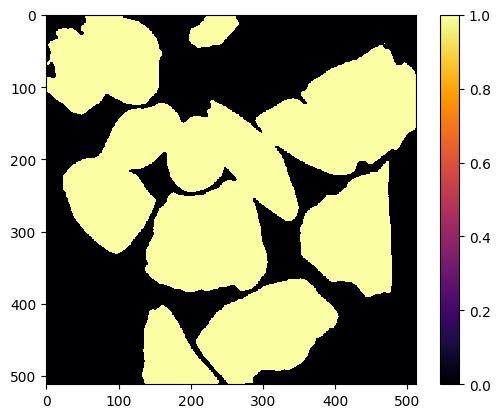

Label


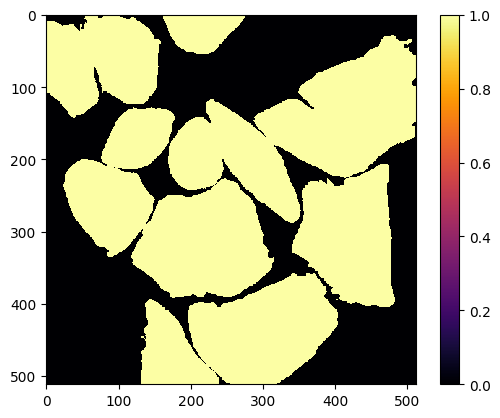

original image


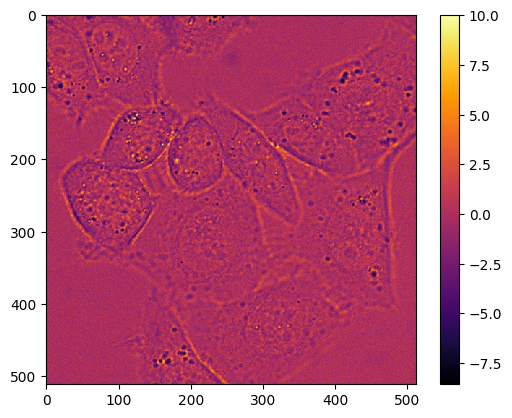

In [171]:
data, label = val_dataset[50]
model.eval()
model.to(device)
model_output = model.generate_numpy_output_from_single_image(data.unsqueeze(1).to(device))

print('Model output')
plot_heatmap(model_output)

print('Label')
plot_heatmap(label.squeeze().numpy())

print('original image')
plot_heatmap(data.squeeze().numpy())